# Lecture 24: Deep Learning II
## Representations, Sequence Models, Attention, and LLMs

**F&W ECOL 458 — Environmental Data Science**

### The story of this lecture

All machine learning pipelines share one structure:

> **Encode** the input → build a **representation** → **decode** the representation into an output.

This lecture follows that structure from the simplest case to modern large language models:

1. **Representations** — feature engineering, embeddings, encoder–decoder pairs, and learned features. Four names, one idea.
2. **Sequential data** — why time series and text need memory; the RNN idea.
3. **LSTMs** — gated memory for long sequences.
4. **Hands-on** — RNN vs. LSTM on a real environmental temperature record.
5. **Attention** — letting the model decide what to focus on (brief, intuition-first).
6. **Brief introduction to Transformer**
7. **Matching architecture to data.**

## Learning objectives

By the end of this lecture, you should be able to:

- Describe the **encode → represent → decode** structure shared by all ML pipelines.
- Explain **feature engineering** and how it differs from **learned representations**.
- Explain what an **embedding** is, and how embeddings, feature engineering, encoders, and decoders are all the same underlying idea applied to different kinds of data.
- Explain why sequential data are hard for ordinary feed-forward networks, and what an **RNN** does about it.
- Describe the **hidden state**, **cell state**, and three **gates** in an LSTM.
- Give the intuition for **self-attention** using the Query/Key/Value picture.
- Have a sense of Transformer
- Match common environmental data problems to appropriate model architectures.

In [36]:
# Core packages used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(42)

# Make figures readable in a classroom setting
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# 1. Representations: how a model sees the world

A machine learning model does not directly understand words like

- "spring green-up"
- "dry conditions"
- "a heat wave"
- "a forested landscape"
- "a sentence"

It only sees numbers. So the first major question of every ML pipeline is:

> **How should we turn the real world into numbers a model can use?**

Before we examine any single model, it helps to have one picture that organizes everything that follows.

### 1.0 A unifying framework: encode → represent → decode

| Stage | What happens | Who does it |
|---|---|---|
| **Encoder** | Turn raw input into a useful representation | Feature engineering (manual), embeddings (learned for discrete items), or neural-network layers (learned end-to-end) |
| **Representation** | A vector (or set of vectors) capturing what matters | Engineered features, embedding vectors, hidden states, attention outputs |
| **Decoder** | Map the representation to a prediction or output | Linear layer, recurrent layer, or another neural network |

This framework applies at every scale of the lecture:

- **Classical ML**: you *engineer* features (encode), then fit a model (decode).
- **Deep learning**: neural layers *learn* both the encoder and decoder jointly.
- **Embeddings**: a small learned encoder for discrete categories (words, species, stations).
- **LSTMs**: the recurrent network encodes a sequence step by step; a final layer decodes.
- **Seq2seq / U-Net / Transformers**: the encoder and decoder are explicit modules.

The rest of the lecture repeatedly fills in *what* the encoder is and *how* it is built.

## 1.1 Feature engineering — a manual encoder for continuous data

A **feature** is an input variable used by a model. Some features are measured directly:

- temperature, precipitation, soil moisture, elevation, NDVI, land cover class.

Other features are **engineered** from raw data using domain knowledge:

- day-of-year → seasonal sine/cosine terms,
- previous-day NDVI (a lag),
- 7-day rolling precipitation,
- a drought index,
- distance to road,
- one-hot encoded land cover,
- interactions such as temperature × soil moisture.

Feature engineering is a *manual* encoder: the human decides which transformation of the raw data makes patterns easier for the model to learn.

In [37]:
# Create a small synthetic environmental table just to demonstrate engineered features.
# (For the real hands-on example later, we use a real temperature dataset.)
n_days = 365
day = np.arange(1, n_days + 1)

temperature = 10 + 15 * np.sin(2 * np.pi * (day - 80) / 365) + np.random.normal(0, 2, n_days)
precip = np.random.gamma(shape=1.5, scale=3.0, size=n_days)
soil_moisture = 0.25 + 0.08 * np.sin(2 * np.pi * (day - 40) / 365) + 0.01 * np.random.randn(n_days)

ndvi = (
    0.35
    + 0.30 * np.sin(2 * np.pi * (day - 120) / 365)
    + 0.003 * temperature
    + 0.15 * soil_moisture
    + np.random.normal(0, 0.03, n_days)
)
ndvi = np.clip(ndvi, 0.05, 0.9)

df = pd.DataFrame({
    "day_of_year": day,
    "temperature_C": temperature,
    "precip_mm": precip,
    "soil_moisture": soil_moisture,
    "NDVI": ndvi,
})

# Engineered features
df["season_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["season_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
df["NDVI_lag_1day"] = df["NDVI"].shift(1)
df["precip_7day_sum"] = df["precip_mm"].rolling(7).sum()
df["temp_x_soil_moisture"] = df["temperature_C"] * df["soil_moisture"]

df.head(10)

,day_of_year,temperature_C,precip_mm,soil_moisture,NDVI,season_sin,season_cos,NDVI_lag_1day,precip_7day_sum,temp_x_soil_moisture
0,1,-3.674297,2.354231,0.195404,0.082164,0.017213,0.999852,NaN,NaN,-0.717974
1,2,-4.888035,3.730587,0.217062,0.067736,0.034422,0.999407,0.082164,NaN,-1.061005
2,3,-3.255582,7.752061,0.190164,0.113851,0.051620,0.998667,0.067736,NaN,-0.619095
3,4,-1.440039,5.269980,0.188892,0.136403,0.068802,0.997630,0.113851,NaN,-0.272012
4,5,-4.885254,3.679087,0.206908,0.112674,0.085965,0.996298,0.136403,NaN,-1.010800
5,6,-4.811796,2.278631,0.216276,0.120600,0.103102,0.994671,0.112674,NaN,-1.040677
6,7,-1.107422,13.648371,0.223799,0.078327,0.120208,0.992749,0.120600,38.712947,-0.247840
7,8,-2.649076,3.152705,0.203538,0.050000,0.137279,0.990532,0.078327,39.511421,-0.539187
8,9,-5.036790,7.712512,0.220093,0.130115,0.154309,0.988023,0.050000,43.493346,-1.108563
9,10,-2.922438,3.013389,0.210113,0.078561,0.171293,0.985220,0.130115,38.754675,-0.614042


| Engineered feature | Why it helps |
|---|---|
| `season_sin`, `season_cos` | Puts the year on a circle, so day 365 and day 1 are neighbors |
| `NDVI_lag_1day` | Gives short-term memory |
| `precip_7day_sum` | Captures recent accumulated wetness |
| `temp_x_soil_moisture` | Lets temperature effects depend on water availability |

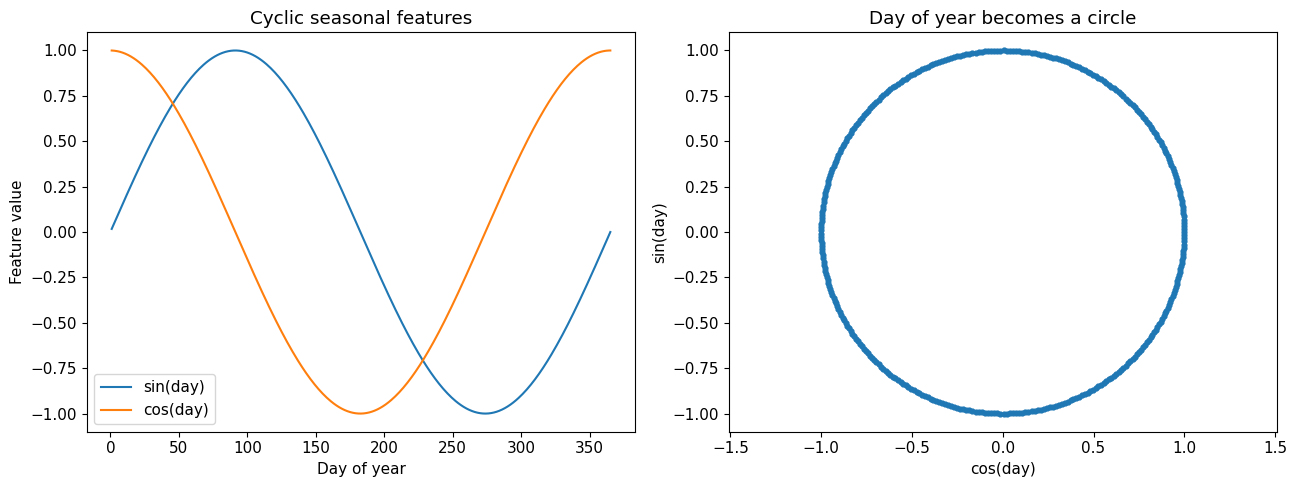

In [38]:
# Why cyclic features? Day 365 and day 1 are adjacent in the real cycle,
# but as integers they look 364 apart. Sin/cos puts them on a circle.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df["day_of_year"], df["season_sin"], label="sin(day)")
axes[0].plot(df["day_of_year"], df["season_cos"], label="cos(day)")
axes[0].set_title("Cyclic seasonal features")
axes[0].set_xlabel("Day of year")
axes[0].set_ylabel("Feature value")
axes[0].legend()

axes[1].scatter(df["season_cos"], df["season_sin"], s=12)
axes[1].set_title("Day of year becomes a circle")
axes[1].set_xlabel("cos(day)")
axes[1].set_ylabel("sin(day)")
axes[1].axis("equal")

plt.tight_layout()
plt.show()

### Connecting to the framework

Feature engineering **is a hand-built encoder**. You, the scientist, look at raw inputs and produce a numeric representation that is easier for a downstream model to use.
The next sections show two other kinds of encoders — embeddings and neural network layers — that do the same job differently.

## 1.2 Embeddings — a learned encoder for discrete data

Feature engineering works well for numeric variables. But many important inputs are **discrete categories**:

- words and tokens,
- land-cover types,
- species IDs,
- station IDs,
- sensor IDs,
- crop types.

A model cannot directly use the word `"forest"` or the category `"grassland"`. The simplest option is **one-hot encoding**:

| Category | One-hot vector |
|---|---|
| forest | [1, 0, 0, 0] |
| grassland | [0, 1, 0, 0] |
| cropland | [0, 0, 1, 0] |
| urban | [0, 0, 0, 1] |

One-hot vectors are large (one dimension per category) and they express no similarity — every pair of categories is equally far apart in that space.

An **embedding** replaces the one-hot vector with a short dense vector whose coordinates are **learned** during training:

| Category | Learned embedding |
|---|---|
| forest | [0.80, 0.25] |
| grassland | [0.55, 0.45] |
| cropland | [0.25, 0.70] |
| urban | [-0.45, 0.85] |

Embeddings are chosen so that categories which *behave similarly* for the task end up *near each other* in the space. If the task rewards grouping "forest" and "grassland" (because both are natural vegetation), training pushes their vectors together.

In [39]:
# One-hot vs. embedding lookup
categories = ["forest", "grassland", "cropland", "urban"]
category_to_id = {cat: i for i, cat in enumerate(categories)}

one_hot = np.eye(len(categories))

# A small hand-designed embedding matrix, for illustration.
# In real deep learning these numbers are learned.
embedding_matrix = np.array([
    [0.80, 0.25],   # forest
    [0.55, 0.45],   # grassland
    [0.25, 0.70],   # cropland
    [-0.45, 0.85],  # urban
])

example = "grassland"
idx = category_to_id[example]
print(f"Category: {example}")
print(f"Integer ID: {idx}")
print(f"One-hot vector:   {one_hot[idx]}")
print(f"Embedding vector: {embedding_matrix[idx]}")

Category: grassland
Integer ID: 1
One-hot vector:   [0. 1. 0. 0.]
Embedding vector: [0.55 0.45]


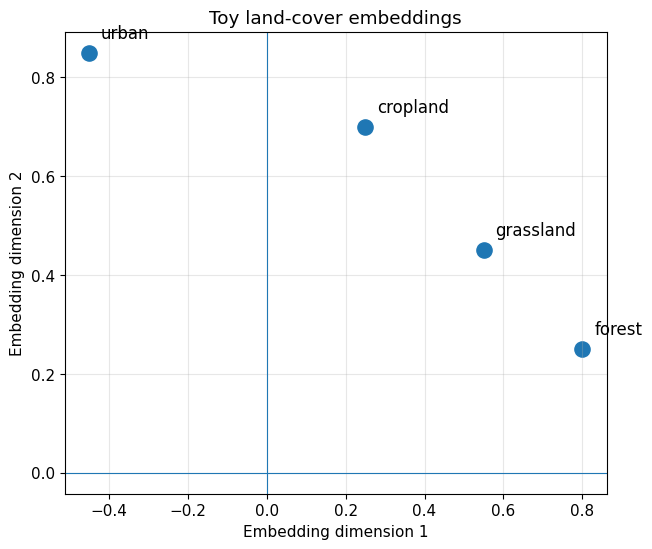

In [40]:
# Visualize the toy embeddings
plt.figure(figsize=(7, 6))
plt.scatter(embedding_matrix[:, 0], embedding_matrix[:, 1], s=120)
for cat, (x, y) in zip(categories, embedding_matrix):
    plt.text(x + 0.03, y + 0.03, cat, fontsize=12)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Embedding dimension 1")
plt.ylabel("Embedding dimension 2")
plt.title("Toy land-cover embeddings")
plt.grid(alpha=0.3)
plt.show()

### Embeddings are encoders, too

Notice the pattern:

- Cyclic features encoded **day-of-year** into two numbers whose geometry (a circle) reflects seasonal structure.
- Embeddings encode **categories** into two-or-more numbers whose geometry (nearness in a vector space) reflects behavioral similarity.

Both are "encoders." The difference is only **who decides the coordinates**: you (engineering) or the model (learning).

In language models, embeddings are the very first thing that happens to a token. Each word or sub-word token is looked up in a giant embedding table before any Transformer layer runs. Embeddings are what turn `"Environmental"`, `"data"`, `"science"` into vectors that the network can manipulate.

## 1.3 Learned representations — when the encoder itself is a neural network

Feature engineering has limits:

| Data type | Why hand-crafted features become hard |
|---|---|
| Images | Which texture, edge, or spatial pattern should we define by hand? |
| Time series | Which lags, windows, and anomalies should we include? |
| Text | How do we represent meaning, grammar, and context? |
| Hyperspectral data | Which bands, ratios, and spectral shapes matter? |
| Genomics | Which motifs and long-range interactions matter? |

Deep learning shifts the work from the human to the model:

> **Classical ML:** raw data → human-designed features → model → prediction
>
> **Deep learning:** raw data → neural network layers → *learned* representation → prediction

Hidden layers discover intermediate representations that may correspond to edges, textures, temporal patterns, topics, or other abstractions — without being told to.

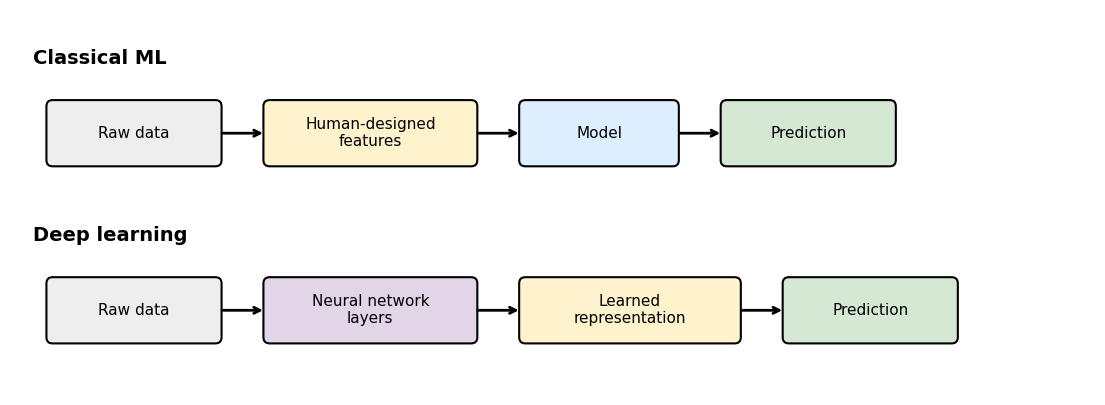

In [41]:
# Diagram: classical feature engineering vs. deep learning representation learning
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")
ax.set_xlim(0, 14); ax.set_ylim(0, 5)

def draw_box(x, y, w, h, text, facecolor):
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5, edgecolor="black", facecolor=facecolor)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=11)

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=2))

# Classical ML
ax.text(0.3, 4.3, "Classical ML", fontsize=14, fontweight="bold")
draw_box(0.5, 3.0, 2.2, 0.8, "Raw data", "#EEEEEE")
draw_box(3.3, 3.0, 2.7, 0.8, "Human-designed\nfeatures", "#FFF3CD")
draw_box(6.6, 3.0, 2.0, 0.8, "Model", "#DDEEFF")
draw_box(9.2, 3.0, 2.2, 0.8, "Prediction", "#D5E8D4")
arrow(2.7, 3.4, 3.3, 3.4); arrow(6.0, 3.4, 6.6, 3.4); arrow(8.6, 3.4, 9.2, 3.4)

# Deep learning
ax.text(0.3, 2.0, "Deep learning", fontsize=14, fontweight="bold")
draw_box(0.5, 0.7, 2.2, 0.8, "Raw data", "#EEEEEE")
draw_box(3.3, 0.7, 2.7, 0.8, "Neural network\nlayers", "#E1D5E7")
draw_box(6.6, 0.7, 2.8, 0.8, "Learned\nrepresentation", "#FFF3CD")
draw_box(10.0, 0.7, 2.2, 0.8, "Prediction", "#D5E8D4")
arrow(2.7, 1.1, 3.3, 1.1); arrow(6.0, 1.1, 6.6, 1.1); arrow(9.4, 1.1, 10.0, 1.1)

plt.show()

### The mental model

A deep network is a **sequence of representation transformations**. For example:

- **Image model:** pixels → edges → textures → object parts → objects → class label
- **Language model:** tokens → word meaning → phrase meaning → sentence context → next-token prediction
- **Environmental time-series model:** daily observations → short-term weather patterns → seasonal dynamics → disturbance signals → forecast

The architecture determines *what kinds* of patterns the model can learn efficiently.

## 1.4 Putting it together: encoders and decoders in practice

When both the input and the output are structured (both are sequences, or both are images), we often split the network explicitly into two parts:

- **Encoder**: reads the input and builds a representation.
- **Decoder**: uses that representation to generate the output.

The encoder can be an LSTM, a CNN, a Transformer, or anything else — what matters is that it produces a representation the decoder can use.

**Everything so far — feature engineering, embeddings, neural layers — is a kind of encoder.** The rest of this notebook looks at *specific* encoder designs for sequences.

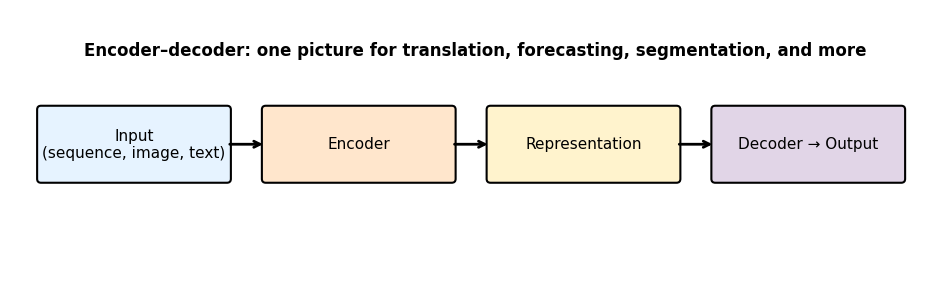

In [42]:
# A compact encoder-decoder schematic
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off"); ax.set_xlim(0, 12); ax.set_ylim(0, 3.5)

def box(x, y, w, h, text, color, fs=11):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                  facecolor=color, edgecolor="black", lw=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs)

def arr(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=2))

box(0.4, 1.3, 2.4, 0.9, "Input\n(sequence, image, text)", "#E6F3FF")
box(3.3, 1.3, 2.4, 0.9, "Encoder", "#FFE6CC")
box(6.2, 1.3, 2.4, 0.9, "Representation", "#FFF3CD")
box(9.1, 1.3, 2.4, 0.9, "Decoder → Output", "#E1D5E7")

arr(2.8, 1.75, 3.3, 1.75)
arr(5.7, 1.75, 6.2, 1.75)
arr(8.6, 1.75, 9.1, 1.75)

ax.text(6, 2.9, "Encoder–decoder: one picture for translation, forecasting, segmentation, and more",
        ha="center", fontsize=12, fontweight="bold")
plt.show()

# 2. Sequential data: when order matters

Many environmental datasets are sequential:

- daily temperature,
- hourly flux-tower measurements,
- annual land-cover change,
- monthly drought indices,
- satellite image time series,
- text reports and scientific abstracts.

For sequential data, **the order of observations carries information**. A feed-forward network can use fixed input features such as

> temperature today, temperature yesterday, temperature two days ago,

but this becomes awkward for long or variable-length sequences, and the model has to learn *from scratch* that position 1 comes before position 2. Recurrent neural networks (RNNs) were designed to build this ordering in.

## 2.1 Recurrent Neural Networks: built for sequence memory

An RNN reads a sequence one step at a time. At each time step it updates a hidden state:

$$
h_t = f(W_x\, x_t + W_h\, h_{t-1} + b)
$$

- $x_t$: input at time $t$,
- $h_t$: hidden state at time $t$,
- $h_{t-1}$: previous hidden state,
- the **same weights** are reused at every time step.

The hidden state acts like a **running memory** of what the model has seen so far — the same person, reading one word at a time, updating their summary after each word.

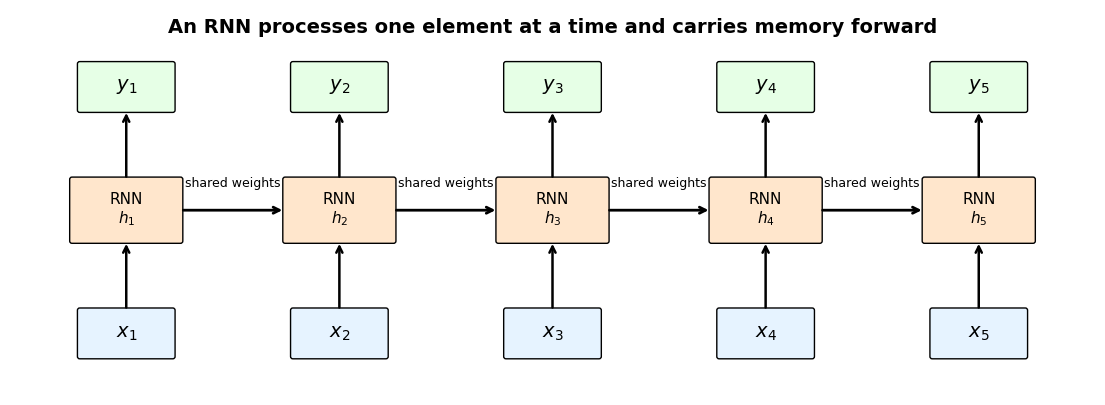

In [43]:
# Visualize an RNN unrolled through time

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")

time_steps = [1, 2, 3, 4, 5]
x_positions = np.linspace(1.5, 12.5, len(time_steps))

for i, (t, x) in enumerate(zip(time_steps, x_positions)):
    # Input
    ax.add_patch(patches.FancyBboxPatch((x-0.6, 0.5), 1.2, 0.6,
                                        boxstyle="round,pad=0.03",
                                        facecolor="#E6F3FF", edgecolor="black"))
    ax.text(x, 0.8, f"$x_{t}$", ha="center", va="center", fontsize=14)

    # Hidden state
    ax.add_patch(patches.FancyBboxPatch((x-0.7, 2.0), 1.4, 0.8,
                                        boxstyle="round,pad=0.03",
                                        facecolor="#FFE6CC", edgecolor="black"))
    ax.text(x, 2.4, f"RNN\n$h_{t}$", ha="center", va="center", fontsize=11)

    # Output
    ax.add_patch(patches.FancyBboxPatch((x-0.6, 3.7), 1.2, 0.6,
                                        boxstyle="round,pad=0.03",
                                        facecolor="#E6FFE6", edgecolor="black"))
    ax.text(x, 4.0, f"$y_{t}$", ha="center", va="center", fontsize=14)

    # Input/output arrows
    ax.annotate("", xy=(x, 2.0), xytext=(x, 1.1),
                arrowprops=dict(arrowstyle="->", lw=1.8))
    ax.annotate("", xy=(x, 3.7), xytext=(x, 2.8),
                arrowprops=dict(arrowstyle="->", lw=1.8))

    # Recurrent arrow
    if i < len(time_steps) - 1:
        x_next = x_positions[i+1]
        ax.annotate("", xy=(x_next-0.7, 2.4), xytext=(x+0.7, 2.4),
                    arrowprops=dict(arrowstyle="->", lw=2))
        ax.text((x+x_next)/2, 2.7, "shared weights", ha="center", fontsize=9)

ax.text(7, 4.7, "An RNN processes one element at a time and carries memory forward",
        ha="center", fontsize=14, fontweight="bold")
plt.show()

## 2.2 The vanishing gradient problem

RNNs are elegant, but they struggle with **long-range dependencies**.

During training, gradients must flow backward through many time steps. If a gradient is repeatedly multiplied by values smaller than 1, it **shrinks toward zero** — the same effect you see compounding interest in reverse. As a result, the model may fail to learn that something early in the sequence matters later.

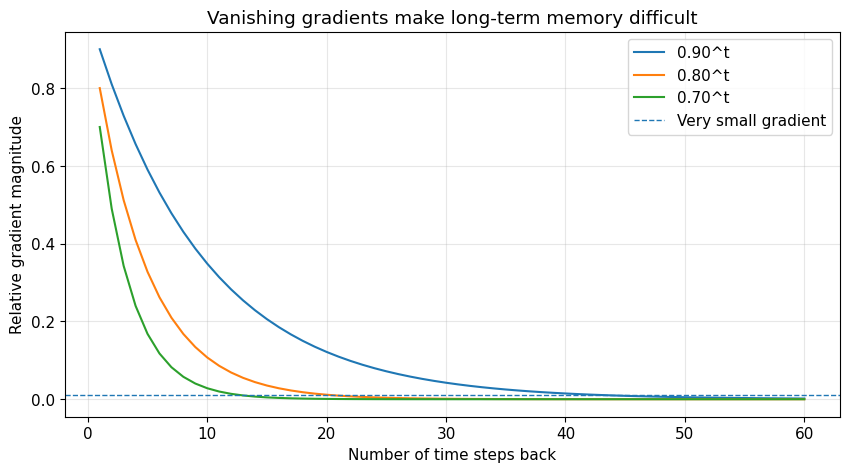

In [44]:
# Visualize gradient decay through time

steps = np.arange(1, 61)
decay_09 = 0.90 ** steps
decay_08 = 0.80 ** steps
decay_07 = 0.70 ** steps

plt.figure(figsize=(10, 5))
plt.plot(steps, decay_09, label="0.90^t")
plt.plot(steps, decay_08, label="0.80^t")
plt.plot(steps, decay_07, label="0.70^t")
plt.axhline(0.01, linestyle="--", linewidth=1, label="Very small gradient")
plt.xlabel("Number of time steps back")
plt.ylabel("Relative gradient magnitude")
plt.title("Vanishing gradients make long-term memory difficult")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Intuition

Imagine forecasting vegetation productivity in August. Relevant signals might include:

- precipitation in June,
- spring green-up timing,
- a heat wave three weeks earlier,
- fire or disturbance history,
- snowmelt timing.

A plain RNN tends to focus on *recent* observations because older information becomes hard to learn from. That is the opening LSTMs were designed to fill.

# 3. LSTMs: RNNs with controlled memory

A **Long Short-Term Memory** network (LSTM) is a special RNN designed to hold on to important information over long sequences. It separates:

- a **hidden state** — short-term working memory, used to produce output,
- a **cell state** — long-term memory that is carried through time with minimal interference,
- three **gates** — learned switches that decide what to forget, what to add, and what to reveal.

The gates are not programmed by hand. They are **learned from data during training**.

## 3.1 The three major LSTM gates

At each time step, an LSTM asks three questions:

1. **Forget gate.** What old information should be removed from the cell state?
2. **Input gate.** What new information should be added?
3. **Output gate.** What part of the cell state should be exposed as the hidden state?

Analogy: the cell state is a **notebook** you carry through time. The forget gate is an **eraser**, the input gate is a **pen**, and the output gate decides **which lines you read aloud** at each step.

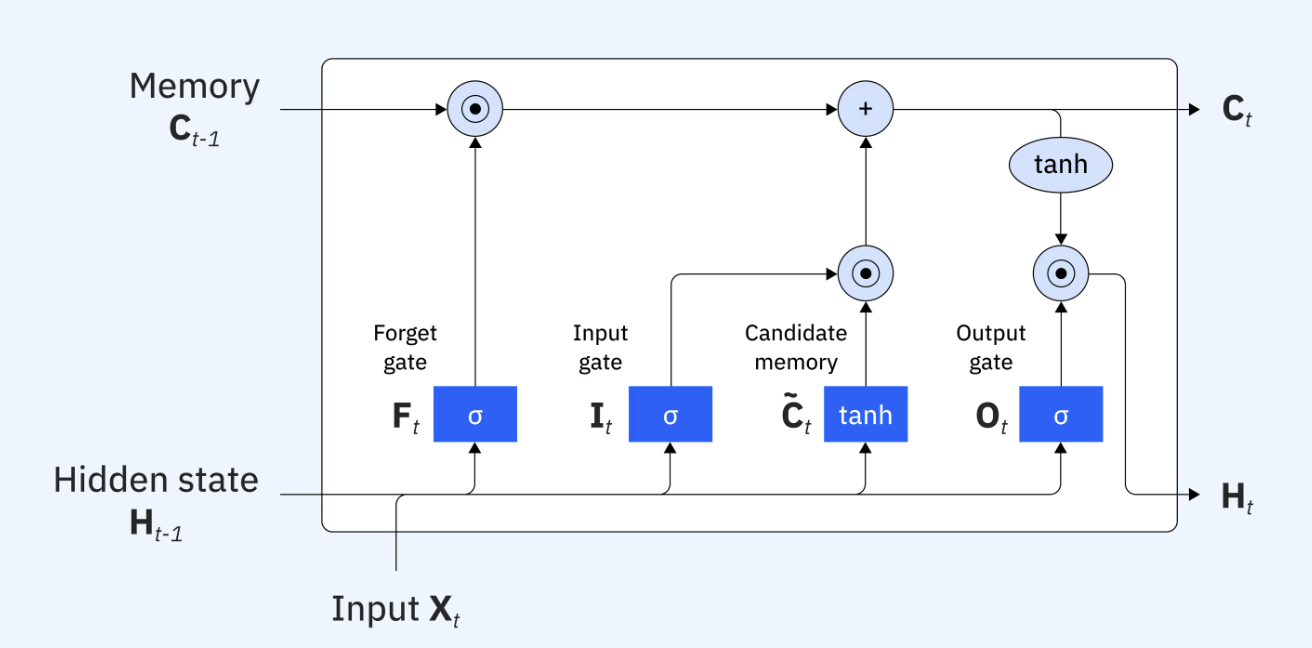

### LSTM Formulas

At time step $t$, an LSTM receives three pieces of information:

- current input: $x_t$
- previous hidden state: $h_{t-1}$
- previous cell state: $C_{t-1}$

It produces:

- new hidden state: $h_t$
- new cell state: $C_t$

The standard LSTM equations are:

$$
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
$$

$$
i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)
$$

$$
C_t = f_t C_{t-1} + i_t \tilde{C}_t
$$

$$
o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \tanh(C_t)
$$

where:

- $f_t$ is the **forget gate**.
- $i_t$ is the **input gate**.
- $\tilde{C}_t$ is the **candidate cell state**.
- $C_t$ is the **updated cell state**, or long-term memory.
- $o_t$ is the **output gate**.
- $h_t$ is the **hidden state**, or short-term output.
- $\sigma$ is the sigmoid function, which outputs values between 0 and 1.
- $\tanh$ is the hyperbolic tangent function, which outputs values between -1 and 1.
- $W_f, W_i, W_C, W_o$ are trainable weight matrices.
- $b_f, b_i, b_C, b_o$ are trainable bias terms.

The most important equation is the cell-state update:

$$
C_t = f_t C_{t-1} + i_t \tilde{C}_t
$$

This equation means:

$$
\text{new memory}
=
\text{kept old memory}
+
\text{stored new memory}
$$

In words:

- $f_t C_{t-1}$ controls how much past memory is retained.
- $i_t \tilde{C}_t$ controls how much new information is added.

# 4. Hands-on: RNN vs. LSTM on a real temperature record

Now let's compare a Simple RNN and an LSTM on a real environmental dataset. Both models will read the past 30 days of daily mean temperature and predict the next day.

### The dataset

We use the **Jena Climate** dataset, recorded by the Max Planck Institute for Biogeochemistry in Jena, Germany. It contains ten-minute weather observations from 2009–2016 (temperature, pressure, humidity, wind, and more). It is one of the canonical real-world datasets for teaching sequence models and is freely hosted on Google Cloud Storage, so Colab can download it in a few seconds.

We'll:

1. Download the CSV,
2. keep the air-temperature column,
3. resample to **daily mean** temperature (simpler to visualize than 10-minute data), and
4. use a 30-day sliding window to predict the next day.

In [45]:
# ── Download the real Jena Climate dataset (≈ 13 MB) ──
import os, urllib.request, zipfile

url      = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = "jena_climate_2009_2016.csv.zip"
csv_path = "jena_climate_2009_2016.csv"

if not os.path.exists(csv_path):
    print("Downloading Jena Climate dataset ...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(".")
    print("Done.")
else:
    print("Dataset already on disk.")

df_raw = pd.read_csv(csv_path)
df_raw["Date Time"] = pd.to_datetime(df_raw["Date Time"], format="%d.%m.%Y %H:%M:%S")
df_raw = df_raw.set_index("Date Time").sort_index()

# Resample 10-minute data to daily mean temperature
temp_daily = df_raw["T (degC)"].resample("1D").mean().dropna()

print(f"Record: {temp_daily.index.min().date()} to {temp_daily.index.max().date()}"
      f"  ({len(temp_daily)} daily observations)")
print(temp_daily.head())

Dataset already on disk.
Record: 2009-01-01 to 2017-01-01  (2921 daily observations)
Date Time
2009-01-01   -6.810629
2009-01-02   -3.728194
2009-01-03   -5.271736
2009-01-04   -1.375208
2009-01-05   -4.867153
Name: T (degC), dtype: float64


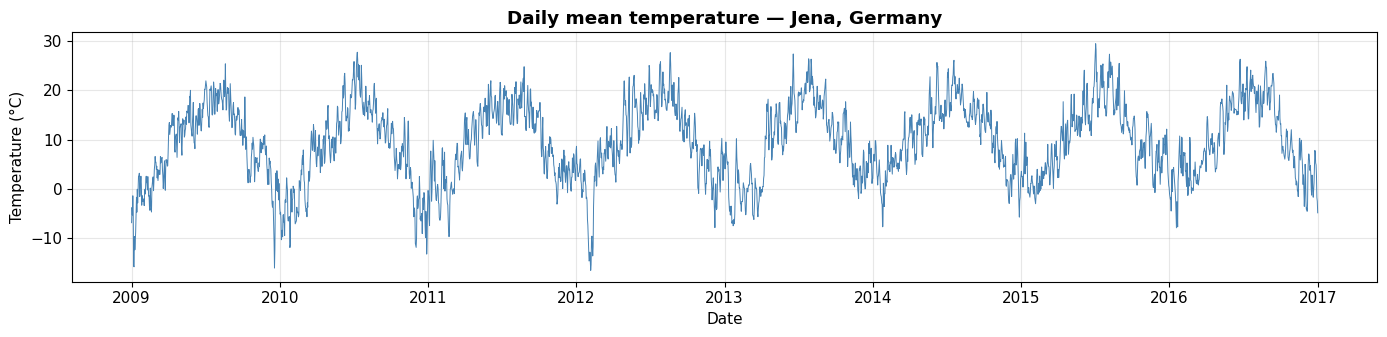

Min -16.5 °C  |  Mean 9.4 °C  |  Max 29.4 °C


In [46]:
# Plot the raw daily record
plt.figure(figsize=(14, 3.5))
plt.plot(temp_daily.index, temp_daily.values, lw=0.7, color="steelblue")
plt.title("Daily mean temperature — Jena, Germany", fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Min {temp_daily.min():.1f} °C  |  Mean {temp_daily.mean():.1f} °C  |  Max {temp_daily.max():.1f} °C")

In [47]:
# ── Prepare sequences: past 30 days → next day ──
from sklearn.preprocessing import MinMaxScaler

temp = temp_daily.values.astype("float32")

scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temp.reshape(-1, 1)).flatten()

window = 30  # days of history used as input
X, y = [], []
for i in range(len(temp_scaled) - window):
    X.append(temp_scaled[i : i + window])
    y.append(temp_scaled[i + window])
X = np.array(X).reshape(-1, window, 1)   # (samples, timesteps, features)
y = np.array(y)

# Chronological split — never shuffle sequences!
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Window size: {window} days → predict day {window + 1}")

X_train: (2312, 30, 1)
X_test:  (579, 30, 1)
Window size: 30 days → predict day 31


In [48]:
# ── Build and train a Simple RNN ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time

tf.random.set_seed(42)

rnn_model = keras.Sequential([
    layers.Input(shape=(window, 1)),
    layers.SimpleRNN(32),
    layers.Dense(1),
])
rnn_model.compile(optimizer="adam", loss="mse")

print("Training Simple RNN ...")
t0 = time.time()
rnn_history = rnn_model.fit(X_train, y_train, epochs=20, batch_size=32,
                            validation_split=0.1, verbose=0)
rnn_time = time.time() - t0
print(f"  Done in {rnn_time:.1f}s  val_loss={rnn_history.history['val_loss'][-1]:.5f}")

rnn_pred_scaled = rnn_model.predict(X_test, verbose=0).flatten()
rnn_pred = scaler.inverse_transform(rnn_pred_scaled.reshape(-1, 1)).flatten()

Training Simple RNN ...
  Done in 11.3s  val_loss=0.00269


In [49]:
# ── Build and train an LSTM ──
tf.random.set_seed(42)

lstm_model = keras.Sequential([
    layers.Input(shape=(window, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse")

print("Training LSTM ...")
t0 = time.time()
lstm_history = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32,
                              validation_split=0.1, verbose=0)
lstm_time = time.time() - t0
print(f"  Done in {lstm_time:.1f}s  val_loss={lstm_history.history['val_loss'][-1]:.5f}")

lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

Training LSTM ...
  Done in 17.4s  val_loss=0.00289


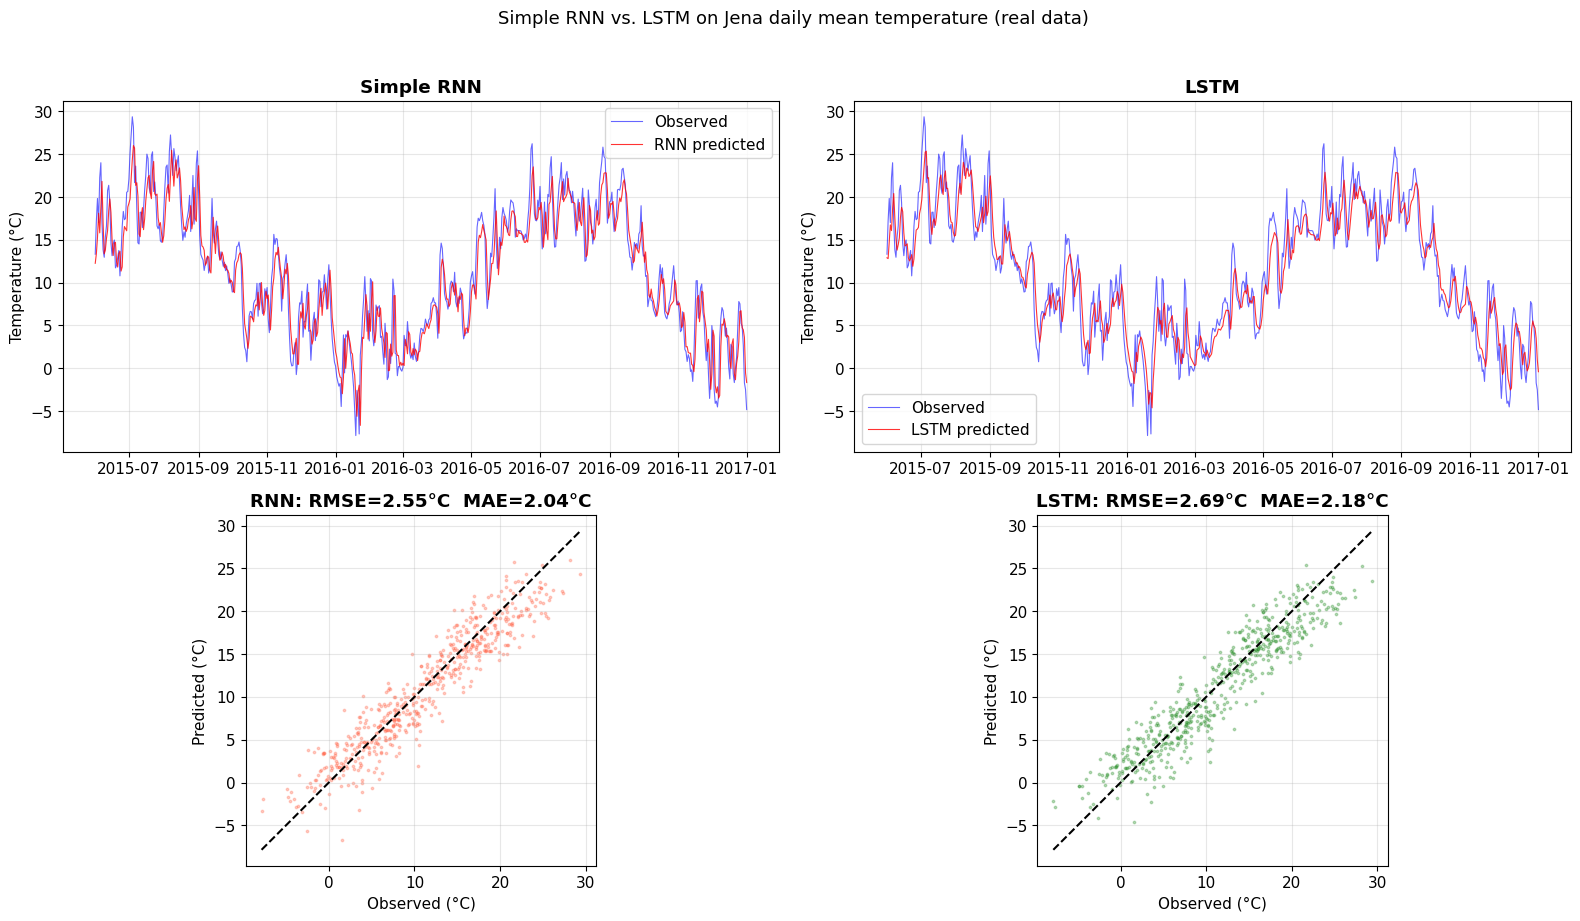

Model          RMSE (°C)    MAE (°C)  Train time
------------------------------------------------
Simple RNN          2.55        2.04       11.3s
LSTM                2.69        2.18       17.4s


In [50]:
# ── Compare RNN vs LSTM ──
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
test_dates = temp_daily.index[split + window:]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes[0, 0].plot(test_dates, y_test_actual, "b-", lw=0.8, alpha=0.6, label="Observed")
axes[0, 0].plot(test_dates, rnn_pred,       "r-", lw=0.8, alpha=0.8, label="RNN predicted")
axes[0, 0].set_title("Simple RNN", fontweight="bold")
axes[0, 0].set_ylabel("Temperature (°C)"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(test_dates, y_test_actual, "b-", lw=0.8, alpha=0.6, label="Observed")
axes[0, 1].plot(test_dates, lstm_pred,     "r-", lw=0.8, alpha=0.8, label="LSTM predicted")
axes[0, 1].set_title("LSTM", fontweight="bold")
axes[0, 1].set_ylabel("Temperature (°C)"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

for ax, pred, name, color in [(axes[1, 0], rnn_pred, "RNN",  "tomato"),
                              (axes[1, 1], lstm_pred, "LSTM", "forestgreen")]:
    ax.scatter(y_test_actual, pred, s=3, alpha=0.3, color=color)
    mn, mx = min(y_test_actual.min(), pred.min()), max(y_test_actual.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], "k--", lw=1.5)
    rmse_v = np.sqrt(mean_squared_error(y_test_actual, pred))
    mae_v  = mean_absolute_error(y_test_actual, pred)
    ax.set_title(f"{name}: RMSE={rmse_v:.2f}°C  MAE={mae_v:.2f}°C", fontweight="bold")
    ax.set_xlabel("Observed (°C)"); ax.set_ylabel("Predicted (°C)")
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

plt.suptitle("Simple RNN vs. LSTM on Jena daily mean temperature (real data)",
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

rnn_rmse  = np.sqrt(mean_squared_error(y_test_actual, rnn_pred))
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
rnn_mae   = mean_absolute_error(y_test_actual, rnn_pred)
lstm_mae  = mean_absolute_error(y_test_actual, lstm_pred)

print(f"{'Model':<12s}  {'RMSE (°C)':>10s}  {'MAE (°C)':>10s}  {'Train time':>10s}")
print("-" * 48)
print(f"{'Simple RNN':<12s}  {rnn_rmse:>10.2f}  {rnn_mae:>10.2f}  {rnn_time:>9.1f}s")
print(f"{'LSTM':<12s}  {lstm_rmse:>10.2f}  {lstm_mae:>10.2f}  {lstm_time:>9.1f}s")

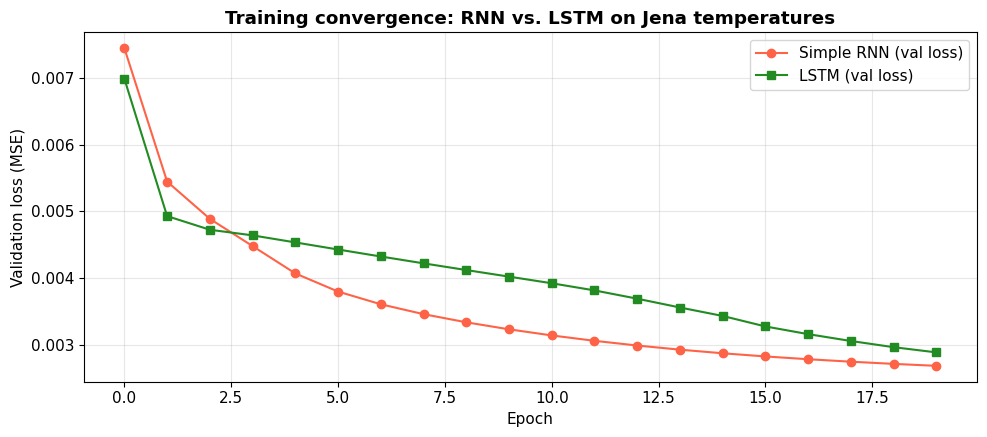

In [51]:
# ── Training convergence ──
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(rnn_history.history["val_loss"],  "o-", label="Simple RNN (val loss)", color="tomato")
ax.plot(lstm_history.history["val_loss"], "s-", label="LSTM (val loss)",       color="forestgreen")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation loss (MSE)")
ax.set_title("Training convergence: RNN vs. LSTM on Jena temperatures", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 5. Attention: letting the model decide what to focus on

### The problem with sequential memory

We just saw that LSTMs improve on basic RNNs by adding gated memory. But even LSTMs have a fundamental limitation: all information about the past is compressed into a single hidden-state vector. That vector has a fixed size (say, 32 or 64 numbers), no matter how long the input sequence is.

Imagine trying to predict tomorrow's temperature. Useful clues might include:
- yesterday's temperature (1 day ago)
- a cold front that passed through (5 days ago)
- the seasonal baseline (the same date last year, ~365 days ago)

In an LSTM, all of these must be crammed into one hidden-state vector. The model has no way to go back and selectively "look at" the cold front event or last year's date. It can only use whatever survived the sequential compression.

**What if the model could look back at the entire input sequence and decide, for each prediction, which past time steps matter most?**

That is the idea behind attention.

### The attention idea, step by step

Let's build the intuition with a concrete example before introducing any formulas or terminology.

Suppose we have a 5-day temperature sequence and we want to predict day 6. The model has processed all 5 days and produced a hidden representation for each one. Now, instead of using only the final hidden state (day 5), we ask:

> "For predicting day 6, how relevant is each of the 5 past days?"

The model computes a **relevance score** for each past day, converts those scores into **weights** that sum to 1 (using softmax), and then computes a **weighted average** of all past representations. The result is a context vector that emphasizes the most relevant days.

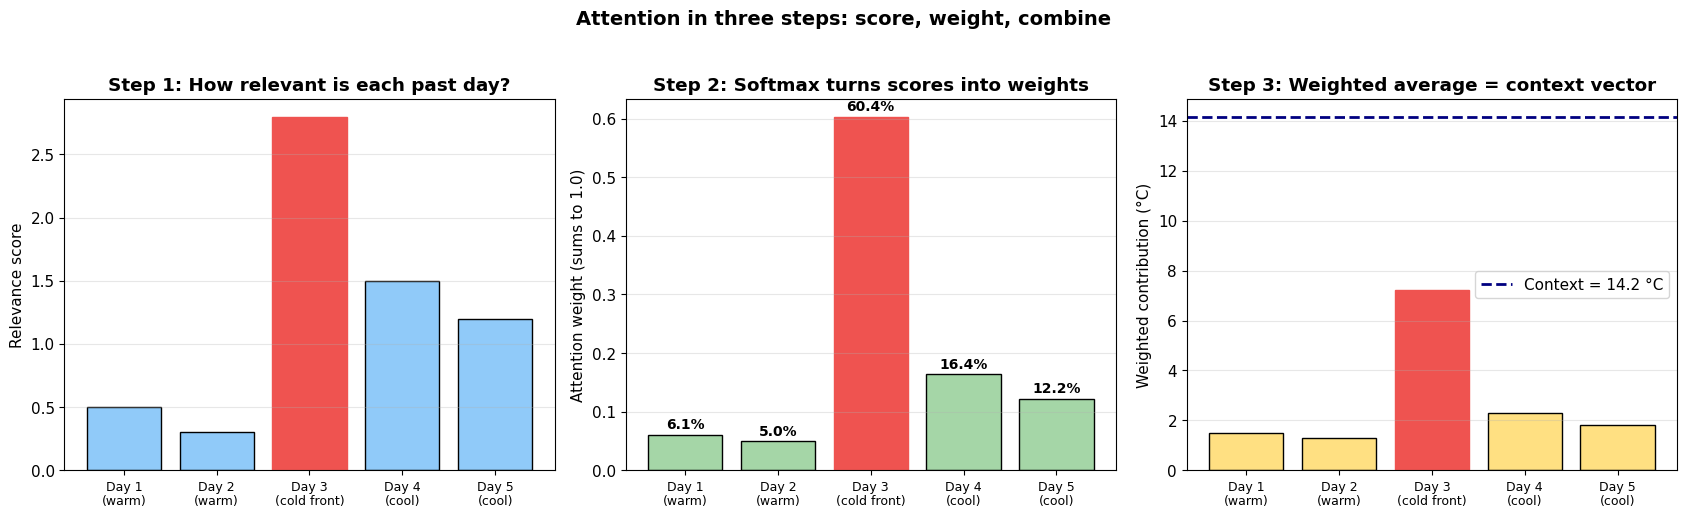

Step 1 — Raw relevance scores: {'Day 1': np.float64(0.5), 'Day 2': np.float64(0.3), 'Day 3': np.float64(2.8), 'Day 4': np.float64(1.5), 'Day 5': np.float64(1.2)}
Step 2 — Softmax weights:      {'Day 1': '6.1%', 'Day 2': '5.0%', 'Day 3': '60.4%', 'Day 4': '16.4%', 'Day 5': '12.2%'}
Step 3 — Weighted average:      14.2 °C

The model 'pays attention' mostly to Day 3 (the cold front),
because it is the most informative for predicting what comes next.


In [52]:
# ── Step-by-step attention example with numbers ──
import numpy as np
import matplotlib.pyplot as plt

# Suppose we have 5 past days, each represented by a small vector
# (in a real model these would be learned hidden states)
np.random.seed(42)

days = ['Day 1\n(warm)', 'Day 2\n(warm)', 'Day 3\n(cold front)', 'Day 4\n(cool)', 'Day 5\n(cool)']
temps = [25, 26, 12, 14, 15]  # actual temperatures for context

# Step 1: Compute a relevance score for each past day
# (In a real model, these come from comparing learned vectors.
#  Here we'll set them manually to illustrate the idea.)
raw_scores = np.array([0.5, 0.3, 2.8, 1.5, 1.2])
# Day 3 (cold front) is most relevant for predicting what comes next

# Step 2: Convert scores to weights using softmax
def softmax(x):
    e = np.exp(x - np.max(x))  # subtract max for numerical stability
    return e / e.sum()

weights = softmax(raw_scores)

# Step 3: Weighted average (the "attention output")
context_temp = np.sum(weights * np.array(temps))

# ── Visualize the three steps ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: Raw scores
ax = axes[0]
bars = ax.bar(range(5), raw_scores, color='#90CAF9', edgecolor='black')
bars[2].set_color('#EF5350')  # highlight day 3
ax.set_xticks(range(5))
ax.set_xticklabels(days, fontsize=9)
ax.set_ylabel('Relevance score')
ax.set_title('Step 1: How relevant is each past day?', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel 2: Softmax weights
ax = axes[1]
bars = ax.bar(range(5), weights, color='#A5D6A7', edgecolor='black')
bars[2].set_color('#EF5350')
for j, w in enumerate(weights):
    ax.text(j, w + 0.01, f'{w:.1%}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(5))
ax.set_xticklabels(days, fontsize=9)
ax.set_ylabel('Attention weight (sums to 1.0)')
ax.set_title('Step 2: Softmax turns scores into weights', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel 3: Weighted combination
ax = axes[2]
contributions = weights * np.array(temps)
bars = ax.bar(range(5), contributions, color='#FFE082', edgecolor='black')
bars[2].set_color('#EF5350')
ax.axhline(context_temp, color='navy', linestyle='--', linewidth=2,
           label=f'Context = {context_temp:.1f} °C')
ax.set_xticks(range(5))
ax.set_xticklabels(days, fontsize=9)
ax.set_ylabel('Weighted contribution (°C)')
ax.set_title('Step 3: Weighted average = context vector', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Attention in three steps: score, weight, combine',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Step 1 — Raw relevance scores:", dict(zip(['Day 1','Day 2','Day 3','Day 4','Day 5'], raw_scores)))
print("Step 2 — Softmax weights:     ", {f'Day {i+1}': f'{w:.1%}' for i, w in enumerate(weights)})
print(f"Step 3 — Weighted average:      {context_temp:.1f} °C")
print(f"\nThe model 'pays attention' mostly to Day 3 (the cold front),")
print(f"because it is the most informative for predicting what comes next.")


### What just happened?

Three simple operations:

1. **Score:** For each past day, compute a number that measures "how relevant is this day for the current prediction?" Day 3 (the cold front) got the highest score.
2. **Weight:** Pass the scores through **softmax**, which converts them into positive weights that sum to 1. Day 3 now gets ~45% of the attention; the warm days (1-2) get very little.
3. **Combine:** Compute a weighted average of all past days' information, using those weights. The result is a context vector that is dominated by the cold front, because the model decided that event is most relevant.

This is the entire attention mechanism. Everything else is about *how the scores are computed*, which brings us to the Query-Key-Value framework.


## 5.1 Query, Key, and Value: how the scores are computed

In the example above, I set the relevance scores by hand. In a real neural network, the scores are computed automatically by comparing **learned vector representations** of each position. The framework uses three vectors per position, with names borrowed from database retrieval:

**Analogy: searching a library catalog**

Imagine you walk into a library looking for information about "cold fronts affecting Midwest agriculture."

- Your **Query** is what you're looking for: "cold fronts + Midwest + agriculture."
- Each book on the shelf has a **Key** (its catalog entry): "Midwestern climate extremes," "Tropical orchid care," "Corn yield and weather variability," etc.
- You compare your Query against each Key. Some match well (high score), some don't (low score).
- For the books that match, you read the actual **Value** (the content inside) and combine them.

Self-attention does the same thing, but every position in the sequence acts as both a searcher and a book:

| Vector | Role | Library analogy |
|---|---|---|
| **Query ($Q$)** | "What am I looking for?" | Your search terms |
| **Key ($K$)** | "What do I contain?" | Each book's catalog entry |
| **Value ($V$)** | "What information do I contribute if selected?" | The actual content of the book |

The relevance score between position $i$ and position $j$ is the **dot product** of $Q_i$ and $K_j$. If the query and key point in similar directions, the score is high (strong match). If they point in different directions, the score is low (weak match). The scores are then passed through softmax (just like Step 2 above) and used to weight the Values.


### The attention formula

The full formula in one line is:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V
$$

where $d_k$ is the dimension of the Key vectors (used for scaling so the dot products don't get too large).

**You do not need to memorize this formula.** Just remember the three steps:

1. **Compare** each Query with every Key (dot product).
2. **Weight** the scores with softmax (so they sum to 1).
3. **Combine** the Values using those weights (weighted average).

Or even shorter: **compare, weight, combine.**

### Why attention solves the long-range problem

In an RNN, information from Day 1 must travel through Days 2, 3, 4, ... to reach Day 100. Each hop degrades the signal (vanishing gradient).

In attention, Day 100 **directly computes a dot product with Day 1** in a single step. There are no intermediate hops. Information from any position can influence any other position equally easily, regardless of distance. This is what makes Transformers so powerful for long sequences.


# 6. Transformers: attention stacked into a deep model

A **Transformer** is a network built around self-attention. Rather than processing tokens one by one, a Transformer lets **all tokens attend to each other in parallel**.

> **Analogy (a committee of highlighters).** One attention layer is a single reader choosing what to highlight. A Transformer stacks many such readers (multiple *heads* per layer, many *layers*). Different readers specialize — one might track grammar, another track topic, a third track long-range references. After several rounds, the representation at each position reflects input from everywhere that mattered.

A Transformer block repeats:

| Component | Role |
|---|---|
| Token / patch embedding | Turn inputs into vectors |
| Positional encoding | Inject order information (attention alone is order-blind) |
| Self-attention | Let each token compare itself with all others |
| Feed-forward layer | Transform each position's vector |
| Residual + LayerNorm | Keep deep networks trainable |

### Three Transformer variants

| Variant | Typical use | Example |
|---|---|---|
| **Encoder-only** | Understand / classify input | BERT-style text classification, Vision Transformers |
| **Decoder-only** | Generate output one step at a time | GPT-style language models |
| **Encoder–decoder** | Convert one sequence into another | Translation, summarization |

### Beyond text

The attention idea applies to *any* data that can be turned into a set of vectors:

- **Vision Transformers (ViT)**: images are split into fixed-size patches; each patch is a token.
- **Time-series Transformers**: each time step or window becomes a token.
- **Environmental foundation models**: satellite patches, climate variables, and land-cover maps can all be tokenized — which is why Transformer-based foundation models are spreading through Earth science.

# 7. Matching architecture to data structure

A good model choice starts with the *structure* of the data and the *goal* of the task.

| Data / task | Natural structure | Common model choices |
|---|---|---|
| Tabular environmental data | rows and columns | Random forest, gradient boosting, feed-forward NN |
| Images | spatial grid | CNN, U-Net, Vision Transformer |
| Time series | ordered sequence | RNN, LSTM, temporal CNN, Transformer |
| Text | token sequence | Transformer, LLM |
| Sequence → sequence | input seq → output seq | Encoder–decoder LSTM or Transformer |
| Category-heavy data | discrete IDs / classes | Embeddings + downstream model |
| Multimodal data | multiple data types | Separate encoders + fusion model |

There is no single best architecture for every problem.

## Further reading

- Olah, C. *Understanding LSTM Networks* (colah.github.io) — the canonical intuition piece.
- Alammar, J. *The Illustrated Transformer* — visual intro to attention and Transformers.
- Vaswani et al. 2017. *Attention Is All You Need.*
- Devlin et al. 2018. *BERT.*
- Brown et al. 2020. *Language Models are Few-Shot Learners.*
- Kratzert et al. 2018. *Rainfall–runoff modelling using LSTMs* — a flagship environmental-science application.